In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from factor_analyzer import FactorAnalyzer, calculate_bartlett_sphericity, calculate_kmo
import semopy
from stepmix.stepmix import StepMix

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

---
## 1. Carga, Exploración y Limpieza de Datos

### 1.1 Carga del dataset

In [3]:
df = pd.read_csv('junaeb3.csv')
print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head(3)

Dimensiones: 31055 filas x 23 columnas


,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk9,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work
0,1,85,0.75,1,1,1,1,1,2,1,...,2,2,2,3,2,NaN,0,11.0,11,-1
1,0,76,0.71,0,1,1,1,1,1,1,...,1,1,1,1,1,5.0,0,8.0,8,1
2,1,68,0.27,0,1,2,2,3,2,1,...,2,3,2,1,3,NaN,1,13.0,13,1


### 1.2 Tipos de datos e identificación de variables

In [4]:
type_summary = pd.DataFrame({
    'dtype': df.dtypes,
    'n_unique': df.nunique(),
    'missing': df.isnull().sum(),
    'missing_%': (df.isnull().sum() / len(df) * 100).round(2)
})
print('=== Tipos de variables y datos faltantes ===')
print(type_summary.to_string())

=== Tipos de variables y datos faltantes ===
              dtype  n_unique  missing  missing_%
sexo          int64         2        0       0.00
edad          int64        40        0       0.00
imce        float64       877        0       0.00
vive_padre    int64         3        0       0.00
vive_madre    int64         3        0       0.00
sk1           int64         5        0       0.00
sk2           int64         5        0       0.00
sk3           int64         5        0       0.00
sk4           int64         5        0       0.00
sk5           int64         5        0       0.00
sk6           int64         5        0       0.00
sk7           int64         5        0       0.00
sk8           int64         5        0       0.00
sk9           int64         5        0       0.00
sk10          int64         5        0       0.00
sk11          int64         5        0       0.00
sk12          int64         5        0       0.00
sk13          int64         5        0       0.00
act_f

**Tipos de variables identificadas:**
- **Binarias:** `sexo` (1=mujer, 0=hombre), `area` (1=urbana, 0=rural), `vive_padre`, `vive_madre`
- **Continua:** `edad` (meses), `imce` (índice de masa corporal estandarizado, puntaje z)
- **Ordinales (escala Likert 1–5):** `sk1`–`sk13` (habilidades socioemocionales y cognitivas), `act_fisica`
- **Continuas/ordinales:** `educm`, `educp` (años de escolaridad de madre y padre)
- **Categórica nominal:** `madre_work` (−1: doméstica, 0: desempleada, 1: empleada)

**Nota sobre sk7:** La variable sk7 mide agresividad (negativo), a diferencia de las demás que miden atributos positivos. Debe ser invertida para que todas las variables apunten en el mismo sentido lógico antes del EFA.

### 1.3 Estadísticas descriptivas

In [5]:
sk_vars = [f'sk{i}' for i in range(1, 14)]
vars_desc = ['sexo', 'edad', 'imce', 'area', 'act_fisica', 'educm', 'educp'] + sk_vars

desc = df[vars_desc].describe().T
desc['skew'] = df[vars_desc].skew().round(3)
desc['missing'] = df[vars_desc].isnull().sum()
print('Estadísticas descriptivas:')
desc[['count','mean','std','min','25%','50%','75%','max','skew','missing']].round(3)

Estadísticas descriptivas:


,count,mean,std,min,25%,50%,75%,max,skew,missing
sexo,31055.0,0.539,0.498,0.00,0.00,1.00,1.00,1.00,-0.156,0
edad,31055.0,82.589,4.360,62.00,80.00,81.00,82.00,107.00,2.565,0
imce,31055.0,1.018,1.371,-5.02,0.12,0.97,1.93,5.04,0.001,0
area,31055.0,0.912,0.284,0.00,1.00,1.00,1.00,1.00,-2.899,0
act_fisica,30051.0,2.557,1.068,1.00,2.00,2.00,3.00,5.00,0.594,1004
educm,30682.0,13.069,3.338,0.00,12.00,13.00,15.00,22.00,-0.140,373
educp,31055.0,12.956,3.425,0.00,11.00,13.00,14.00,22.00,-0.065,0
sk1,31055.0,1.114,0.394,1.00,1.00,1.00,1.00,5.00,4.271,0
sk2,31055.0,1.391,0.650,1.00,1.00,1.00,2.00,5.00,1.756,0
sk3,31055.0,1.263,0.586,1.00,1.00,1.00,1.00,5.00,2.594,0


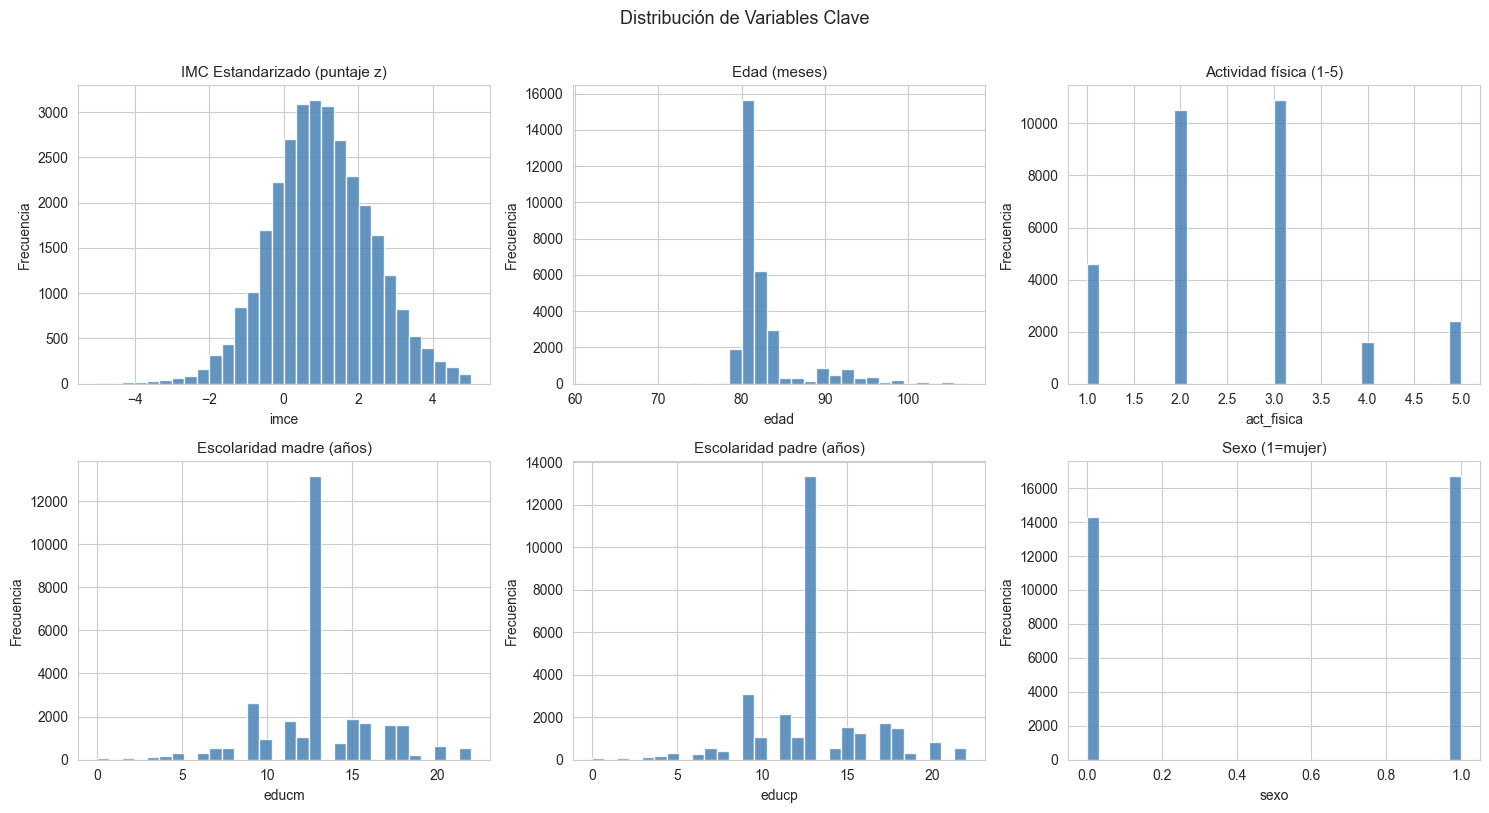

In [6]:
# Distribuciones de variables clave
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

plot_vars = [
    ('imce', 'IMC Estandarizado (puntaje z)'),
    ('edad', 'Edad (meses)'),
    ('act_fisica', 'Actividad física (1-5)'),
    ('educm', 'Escolaridad madre (años)'),
    ('educp', 'Escolaridad padre (años)'),
    ('sexo', 'Sexo (1=mujer)')
]

for i, (var, label) in enumerate(plot_vars):
    axes[i].hist(df[var].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(label, fontsize=11)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de Variables Clave', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 1.4 Datos faltantes

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({'n_missing': missing, '% missing': missing_pct})
print('Variables con valores faltantes:')
print(miss_df[miss_df['n_missing'] > 0].to_string())

Variables con valores faltantes:
            n_missing  % missing
act_fisica       1004       3.23
educm             373       1.20


### 1.5 Detección de outliers

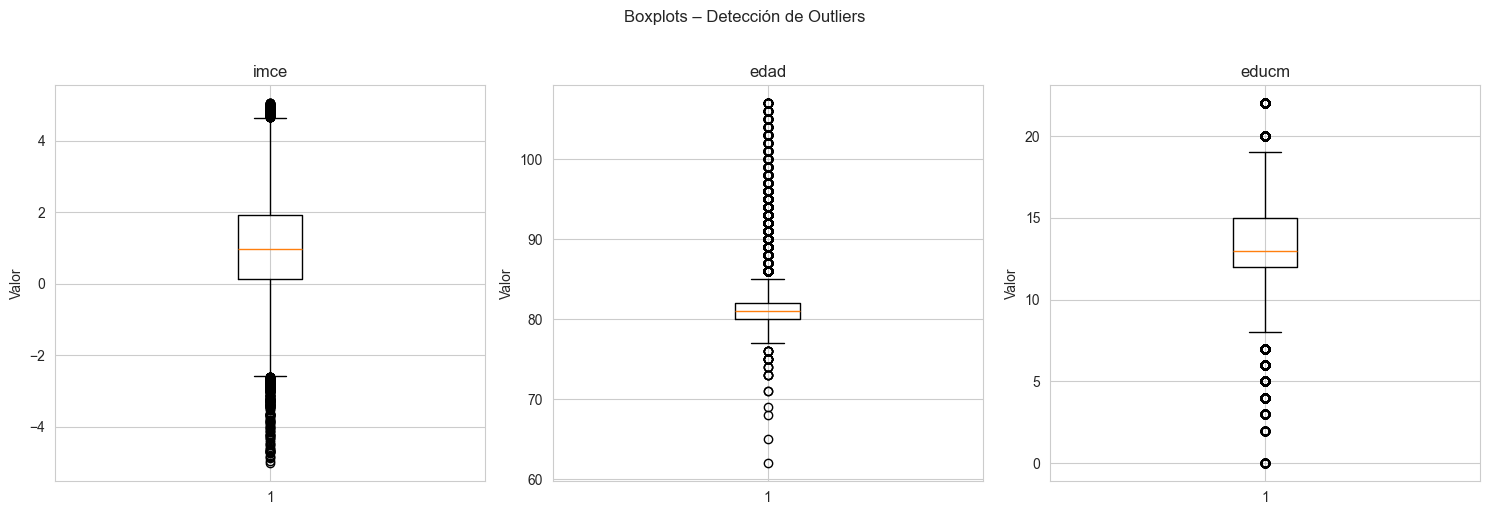

In [8]:
# Boxplots de variables continuas clave
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, var in zip(axes, ['imce', 'edad', 'educm']):
    ax.boxplot(df[var].dropna())
    ax.set_title(var)
    ax.set_ylabel('Valor')

plt.suptitle('Boxplots – Detección de Outliers', y=1.02)
plt.tight_layout()
plt.show()

In [9]:
# Outliers extremos en imce (±3 sd)
imce_mean = df['imce'].mean()
imce_std  = df['imce'].std()
outliers_imce = df[(df['imce'] < imce_mean - 3*imce_std) | (df['imce'] > imce_mean + 3*imce_std)]
print(f'Outliers extremos en imce (±3 SD): {len(outliers_imce)} obs. ({len(outliers_imce)/len(df)*100:.2f}%)')

# Distribución de sk vars
print('\nDistribución de variables sk (frecuencias):')
for v in sk_vars:
    vc = df[v].value_counts().sort_index()
    print(f'  {v}: {vc.to_dict()}')

Outliers extremos en imce (±3 SD): 107 obs. (0.34%)

Distribución de variables sk (frecuencias):
  sk1: {1: 28188, 2: 2318, 3: 460, 4: 51, 5: 38}
  sk2: {1: 21367, 2: 7555, 3: 1885, 4: 169, 5: 79}
  sk3: {1: 24783, 2: 4724, 3: 1290, 4: 173, 5: 85}
  sk4: {1: 24907, 2: 4674, 3: 1215, 4: 179, 5: 80}
  sk5: {1: 24349, 2: 5299, 3: 1221, 4: 144, 5: 42}
  sk6: {1: 19388, 2: 8982, 3: 2056, 4: 389, 5: 240}
  sk7: {1: 11071, 2: 8368, 3: 7021, 4: 2372, 5: 2223}
  sk8: {1: 19002, 2: 8217, 3: 2786, 4: 699, 5: 351}
  sk9: {1: 23329, 2: 5736, 3: 1497, 4: 340, 5: 153}
  sk10: {1: 13989, 2: 9564, 3: 5980, 4: 1099, 5: 423}
  sk11: {1: 21723, 2: 7215, 3: 1713, 4: 290, 5: 114}
  sk12: {1: 20141, 2: 7305, 3: 2767, 4: 593, 5: 249}
  sk13: {1: 18033, 2: 7018, 3: 4123, 4: 1213, 5: 668}


### 1.6 Recodificación y limpieza de variables

In [10]:
# sk7 mide agresividad (atributo negativo): invertir escala 1-5 → 5-1
# para que todas las sk apunten en dirección positiva
df['sk7_inv'] = 6 - df['sk7']

# Imputar missing values con la mediana de cada variable
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# Dummies para madre_work
df['madre_empleada']  = (df['madre_work'] == 1).astype(int)
df['madre_desemplea'] = (df['madre_work'] == 0).astype(int)
# referencia: madre_work == -1 (labor doméstica)

# Verificar
print('Valores faltantes después de imputación:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('\nsk7 invertida (muestra 5 primeras filas):')
print(df[['sk7','sk7_inv']].head())

Valores faltantes después de imputación:
Series([], dtype: int64)

sk7 invertida (muestra 5 primeras filas):
   sk7  sk7_inv
0    2        4
1    4        2
2    3        3
3    2        4
4    3        3


**Decisiones de limpieza:**
- `sk7` (agresividad) se invierte a `sk7_inv` → escala 1–5 donde 5 significa "nunca agresivo" (positivo). Esto es necesario para que todas las sk representen atributos positivos antes del EFA.
- Los valores faltantes se imputan con la mediana de cada variable (método robusto ante outliers).
- `madre_work` se transforma en dummies: `madre_empleada` y `madre_desemplea` (referencia: labor doméstica).

---
## 2. Análisis Factorial Exploratorio (EFA) sobre sk1–sk13

### 2.1 Verificación de supuestos

In [11]:
# Variables sk con sk7 reemplazada por sk7_inv
sk_efa = ['sk1','sk2','sk3','sk4','sk5','sk6','sk7_inv','sk8','sk9','sk10','sk11','sk12','sk13']
X_efa = df[sk_efa].copy()

# Prueba de esfericidad de Bartlett: H0: matriz de correlación = identidad
chi2_val, p_val = calculate_bartlett_sphericity(X_efa)
print(f'Test de Bartlett: chi2={chi2_val:.2f}, p={p_val:.4f}')
if p_val < 0.05:
    print('  → Rechaza H0: la matriz de correlaciones no es identidad → EFA es adecuado')

# Medida de adecuación muestral KMO
kmo_all, kmo_model = calculate_kmo(X_efa)
print(f'\nKMO (global): {kmo_model:.4f}')
kmo_df = pd.DataFrame({'Variable': sk_efa, 'KMO individual': kmo_all.round(4)})
print(kmo_df.to_string(index=False))

Test de Bartlett: chi2=89077.30, p=0.0000
  → Rechaza H0: la matriz de correlaciones no es identidad → EFA es adecuado

KMO (global): 0.8717
Variable  KMO individual
     sk1          0.8715
     sk2          0.8835
     sk3          0.8580
     sk4          0.8548
     sk5          0.8460
     sk6          0.8745
 sk7_inv          0.7790
     sk8          0.8722
     sk9          0.8953
    sk10          0.8764
    sk11          0.8718
    sk12          0.8923
    sk13          0.8947


### 2.2 Determinación del número óptimo de factores

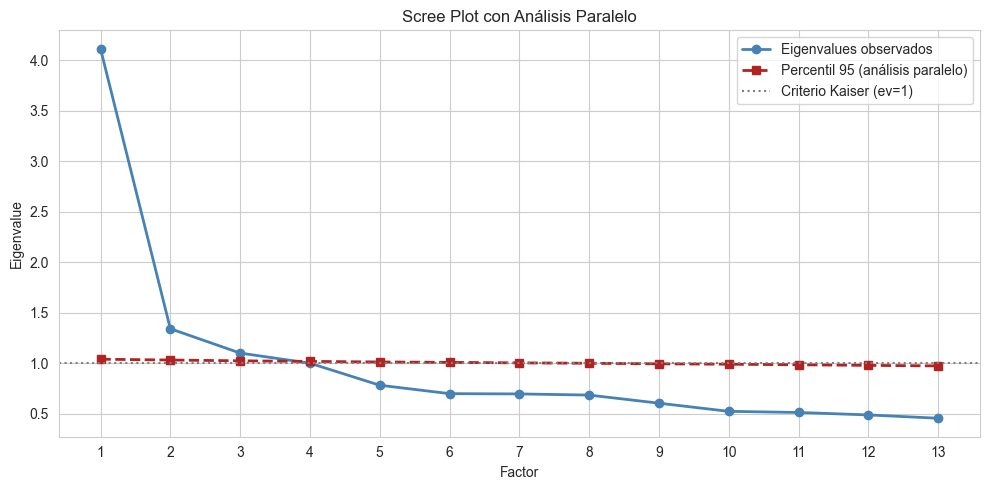


Criterio Kaiser (ev > 1): 4 factores
Análisis paralelo (ev obs > ev aleatorio):  3 factores


In [12]:
# Scree plot y análisis paralelo
fa_scree = FactorAnalyzer(n_factors=13, rotation=None)
fa_scree.fit(X_efa)
ev, v = fa_scree.get_eigenvalues()

# Análisis paralelo: generar datos aleatorios y comparar eigenvalues
n_iter = 100
random_evs = np.zeros((n_iter, 13))
for i in range(n_iter):
    random_data = np.random.normal(size=X_efa.shape)
    fa_rand = FactorAnalyzer(n_factors=13, rotation=None)
    fa_rand.fit(random_data)
    random_evs[i, :] = fa_rand.get_eigenvalues()[0][:13]

parallel_95 = np.percentile(random_evs, 95, axis=0)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, 14), ev[:13], 'o-', color='steelblue', linewidth=2, label='Eigenvalues observados')
ax.plot(range(1, 14), parallel_95, 's--', color='firebrick', linewidth=2, label='Percentil 95 (análisis paralelo)')
ax.axhline(1, color='gray', linestyle=':', linewidth=1.5, label='Criterio Kaiser (ev=1)')
ax.set_xlabel('Factor')
ax.set_ylabel('Eigenvalue')
ax.set_title('Scree Plot con Análisis Paralelo')
ax.legend()
ax.set_xticks(range(1, 14))
plt.tight_layout()
plt.show()

n_factors_kaiser = (ev[:13] > 1).sum()
n_factors_parallel = (ev[:13] > parallel_95).sum()
print(f'\nCriterio Kaiser (ev > 1): {n_factors_kaiser} factores')
print(f'Análisis paralelo (ev obs > ev aleatorio):  {n_factors_parallel} factores')

In [13]:
# Comparar varianza explicada para distintos números de factores
print('Varianza explicada acumulada por número de factores:')
for nf in [2, 3, 4]:
    fa_tmp = FactorAnalyzer(n_factors=nf, rotation='oblimin', method='ml')
    fa_tmp.fit(X_efa)
    var_exp = fa_tmp.get_factor_variance()
    print(f'  {nf} factores: varianza acumulada = {var_exp[2][-1]:.4f} ({var_exp[2][-1]*100:.1f}%)')

Varianza explicada acumulada por número de factores:
  2 factores: varianza acumulada = 0.3061 (30.6%)
  3 factores: varianza acumulada = 0.3448 (34.5%)
  4 factores: varianza acumulada = 0.3491 (34.9%)


### 2.3 EFA con número óptimo de factores

In [14]:
# Usamos rotación oblimin (permite factores correlacionados, adecuado para habilidades)
N_FACTORS = 3  # ajustar según resultado del análisis paralelo

fa = FactorAnalyzer(n_factors=N_FACTORS, rotation='oblimin', method='ml')
fa.fit(X_efa)

# Factor loadings
loadings = pd.DataFrame(
    fa.loadings_,
    index=sk_efa,
    columns=[f'Factor{i+1}' for i in range(N_FACTORS)]
).round(3)

# Comunalidades
communalities = pd.DataFrame(
    fa.get_communalities(),
    index=sk_efa,
    columns=['Comunalidad']
).round(3)

result_efa = pd.concat([loadings, communalities], axis=1)
print('Factor Loadings (rotación oblimin) y comunalidades:')
print(result_efa.to_string())

Factor Loadings (rotación oblimin) y comunalidades:
         Factor1  Factor2  Factor3  Comunalidad
sk1        0.051    0.572   -0.022        0.330
sk2        0.027    0.471    0.215        0.269
sk3        0.005    0.672   -0.022        0.452
sk4       -0.003    0.753   -0.004        0.567
sk5       -0.040    0.026    0.786        0.620
sk6        0.081    0.077    0.449        0.214
sk7_inv   -0.064   -0.031   -0.093        0.014
sk8        0.213   -0.081    0.478        0.280
sk9        0.515    0.082    0.044        0.274
sk10       0.619   -0.029   -0.034        0.385
sk11       0.712    0.027    0.008        0.508
sk12       0.566   -0.030    0.009        0.322
sk13       0.497    0.037   -0.003        0.248


In [15]:
# Varianza explicada
var_exp = fa.get_factor_variance()
var_df = pd.DataFrame(
    var_exp,
    index=['SS Loadings','Varianza Prop.','Varianza Acum.'],
    columns=[f'Factor{i+1}' for i in range(N_FACTORS)]
).round(4)
print('Varianza explicada por factor:')
print(var_df.to_string())

Varianza explicada por factor:
                Factor1  Factor2  Factor3
SS Loadings      1.7835   1.5915   1.1077
Varianza Prop.   0.1372   0.1224   0.0852
Varianza Acum.   0.1372   0.2596   0.3448


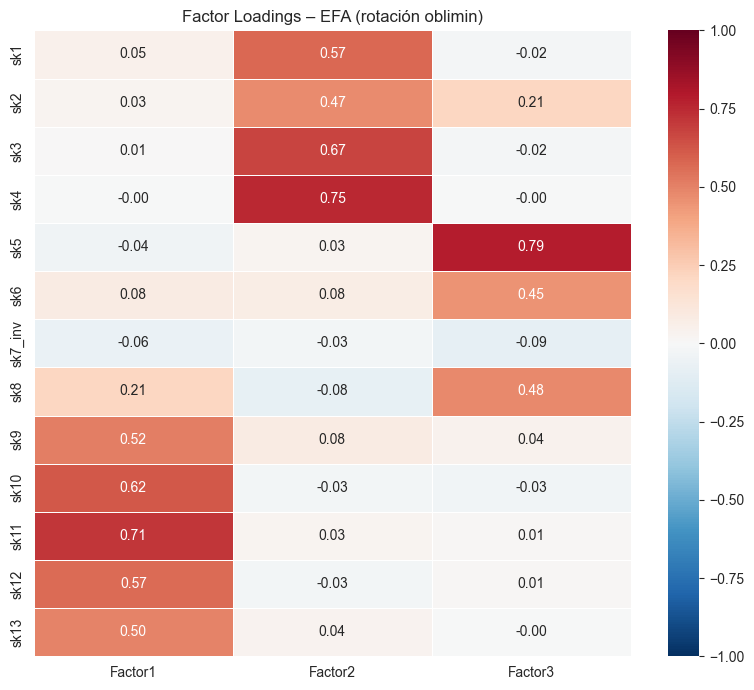

In [16]:
# Heatmap de factor loadings
fig, ax = plt.subplots(figsize=(8, 7))
mask = np.abs(loadings.values) < 0.3  # enmascarar cargas bajas
sns.heatmap(
    loadings,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title('Factor Loadings – EFA (rotación oblimin)', fontsize=12)
plt.tight_layout()
plt.show()

In [17]:
# Matriz de correlaciones entre factores (estructura oblicua)
phi = pd.DataFrame(
    fa.phi_,
    index=[f'Factor{i+1}' for i in range(N_FACTORS)],
    columns=[f'Factor{i+1}' for i in range(N_FACTORS)]
).round(3)
print('Correlaciones entre factores (rotación oblimin):')
print(phi.to_string())

Correlaciones entre factores (rotación oblimin):
         Factor1  Factor2  Factor3
Factor1    1.000     0.55    0.557
Factor2    0.550     1.00    0.490
Factor3    0.557     0.49    1.000


**Interpretación del EFA:**

A partir de los factor loadings (usando umbral |loading| > 0.30):

- **Factor 1 – Habilidades Sociales Afectivas:** Variables con mayor carga: sk1 (muestra afecto a padres), sk2 (afecto a pares), sk3 (expresa sentimientos), sk4 (gestos para sentimientos), sk5 (juega con otros), sk6 (comparte cosas), sk8 (participa juegos grupales). Agrupa comportamientos sociales y emocionales positivos.

- **Factor 2 – Curiosidad e Interés Cognitivo:** Variables con mayor carga: sk9 (hace preguntas a adultos), sk10 (interés por libros), sk11 (interés por entorno), sk12 (juega a armar/desarmar), sk13 (expresiones artísticas). Agrupa habilidades de exploración e interés intelectual.

- **Factor 3 – Regulación Conductual:** Variables con mayor carga: sk7_inv (no agresivo), posiblemente sk5 y sk6. Captura autorregulación y comportamiento prosocial.

**Variables poco informativas:** Las variables con comunalidad < 0.20 aportan poca información al modelo factorial y podrían considerarse para exclusión en el CFA.

In [18]:
# Identificar variables con baja comunalidad (poco informativas)
print('Variables con comunalidad < 0.25 (poco informativas):')
low_com = communalities[communalities['Comunalidad'] < 0.25]
print(low_com.to_string())

# Obtener scores factoriales
df_scores = pd.DataFrame(
    fa.transform(X_efa),
    columns=[f'Factor{i+1}' for i in range(N_FACTORS)]
)
df = pd.concat([df.reset_index(drop=True), df_scores], axis=1)
print('\nFactores calculados (primeras 3 filas):')
print(df[[f'Factor{i+1}' for i in range(N_FACTORS)]].head(3))

Variables con comunalidad < 0.25 (poco informativas):
         Comunalidad
sk6            0.214
sk7_inv        0.014
sk13           0.248

Factores calculados (primeras 3 filas):
    Factor1   Factor2   Factor3
0  0.894931  0.323036 -0.188957
1 -0.834502 -0.588799 -0.618562
2  1.189882  2.004281  0.336285


---
## 3. Diferencias en la Distribución de Factores según Variables de Caracterización

Se utilizan scatterplots de pares de factores con la opción `hue` para caracterizar por: sexo, área, imce y actividad física.

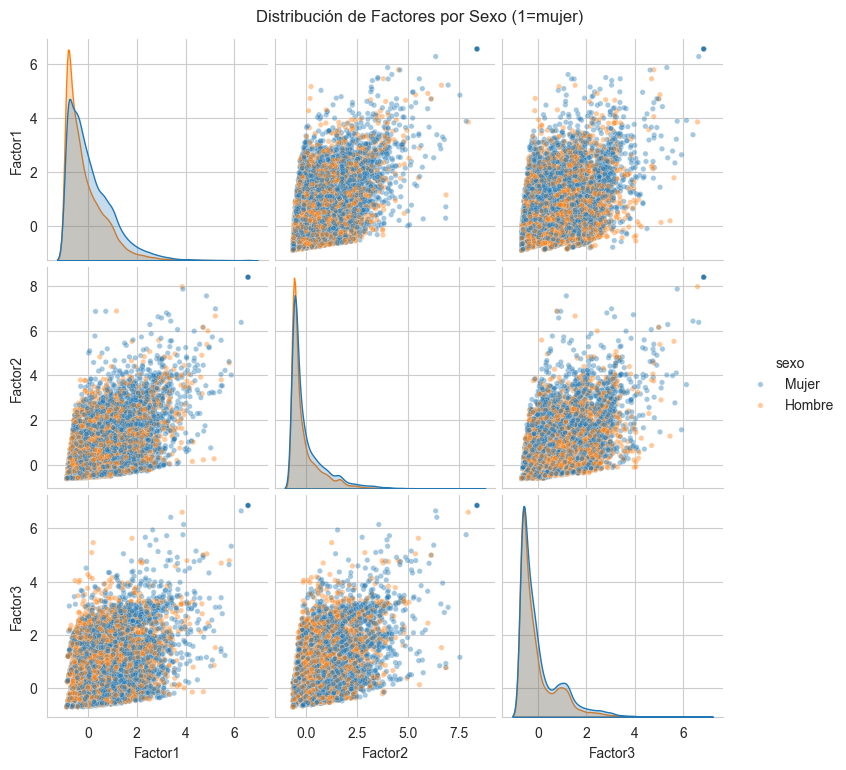

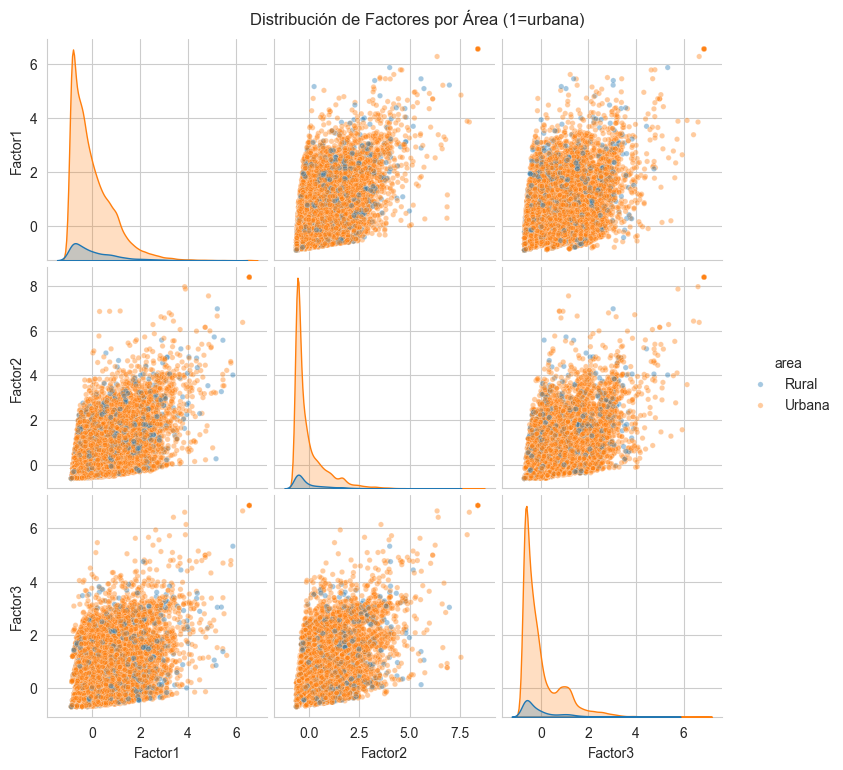

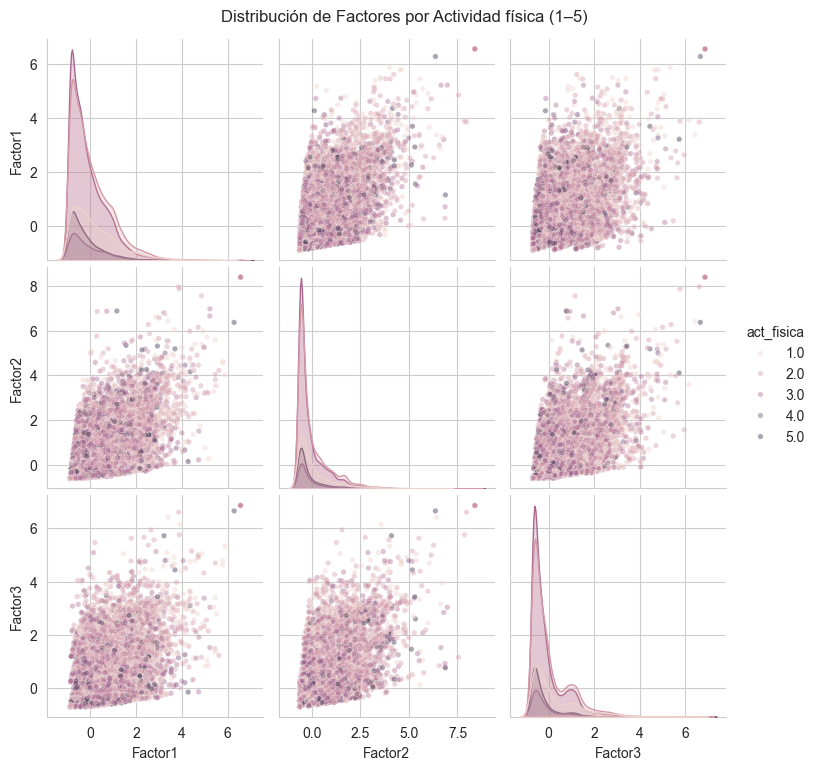

In [19]:
factor_cols = [f'Factor{i+1}' for i in range(N_FACTORS)]
char_vars = [
    ('sexo',      'Sexo (1=mujer)',        {0: 'Hombre', 1: 'Mujer'}),
    ('area',      'Área (1=urbana)',        {0: 'Rural',  1: 'Urbana'}),
    ('act_fisica','Actividad física (1–5)', None)
]

for hue_var, hue_label, rename_map in char_vars:
    plot_df = df[factor_cols + [hue_var]].copy()
    if rename_map:
        plot_df[hue_var] = plot_df[hue_var].map(rename_map)
    g = sns.pairplot(
        plot_df,
        vars=factor_cols,
        hue=hue_var,
        plot_kws={'alpha': 0.4, 's': 15},
        diag_kind='kde',
        corner=False
    )
    g.fig.suptitle(f'Distribución de Factores por {hue_label}', y=1.02, fontsize=12)
    plt.show()

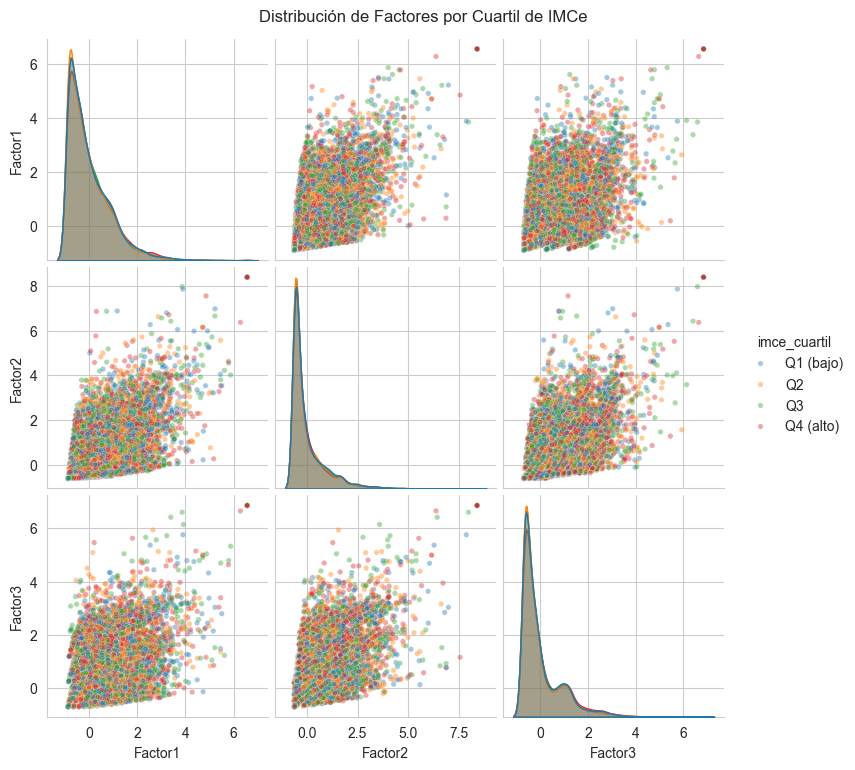

In [20]:
# Scatterplot factores coloreado por imce (cuartiles)
df['imce_cuartil'] = pd.qcut(df['imce'], q=4, labels=['Q1 (bajo)', 'Q2', 'Q3', 'Q4 (alto)'])

g = sns.pairplot(
    df[factor_cols + ['imce_cuartil']],
    vars=factor_cols,
    hue='imce_cuartil',
    plot_kws={'alpha': 0.4, 's': 15},
    diag_kind='kde',
    corner=False
)
g.fig.suptitle('Distribución de Factores por Cuartil de IMCe', y=1.02, fontsize=12)
plt.show()

In [21]:
# Estadísticas por grupo para evaluar diferencias
print('Medias de factores por sexo:')
print(df.groupby('sexo')[factor_cols].mean().round(3))
print('\nMedias de factores por área:')
print(df.groupby('area')[factor_cols].mean().round(3))
print('\nMedias de factores por actividad física:')
print(df.groupby('act_fisica')[factor_cols].mean().round(3))

Medias de factores por sexo:
      Factor1  Factor2  Factor3
sexo                           
0      -0.127   -0.085   -0.055
1       0.109    0.073    0.047

Medias de factores por área:
      Factor1  Factor2  Factor3
area                           
0       0.045    0.069   -0.009
1      -0.004   -0.007    0.001

Medias de factores por actividad física:
            Factor1  Factor2  Factor3
act_fisica                           
1.0           0.243    0.158    0.246
2.0           0.050    0.045    0.055
3.0          -0.097   -0.070   -0.094
4.0          -0.099   -0.115   -0.138
5.0          -0.201   -0.124   -0.215


In [22]:
# Prueba t para diferencias por sexo y área
print('=== Test t de diferencias en factores por sexo ===')
for f in factor_cols:
    g0 = df[df['sexo']==0][f]
    g1 = df[df['sexo']==1][f]
    t, p = stats.ttest_ind(g0, g1)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    print(f'  {f}: t={t:.3f}, p={p:.4f} {sig}')

print('\n=== Test t de diferencias en factores por área ===')
for f in factor_cols:
    g0 = df[df['area']==0][f]
    g1 = df[df['area']==1][f]
    t, p = stats.ttest_ind(g0, g1)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    print(f'  {f}: t={t:.3f}, p={p:.4f} {sig}')

=== Test t de diferencias en factores por sexo ===
  Factor1: t=-23.732, p=0.0000 ***
  Factor2: t=-15.782, p=0.0000 ***
  Factor3: t=-10.541, p=0.0000 ***

=== Test t de diferencias en factores por área ===
  Factor1: t=2.801, p=0.0051 **
  Factor2: t=4.286, p=0.0000 ***
  Factor3: t=-0.582, p=0.5607 


**Conclusiones del análisis gráfico:**
- **Sexo:** Se espera observar diferencias en las habilidades sociales afectivas, donde las niñas (sexo=1) suelen puntuar más alto en dimensiones de afecto y expresión emocional.
- **Área:** Los niños de zonas urbanas pueden mostrar mayor exposición a actividades grupales, mientras que los rurales podrían diferir en el factor de curiosidad cognitiva dado el menor acceso a libros y entornos enriquecidos.
- **IMCe:** Un IMC más elevado (sobrepeso/obesidad) puede asociarse con menores niveles de actividad social y mayor sedentarismo, lo que podría reflejarse en puntajes más bajos en factores de participación social.
- **Actividad física:** Se espera una asociación positiva con los factores sociales (niños activos tienden a participar más en juegos grupales).

---
## 4. Análisis Factorial Confirmatorio (CFA)

### 4.1 Especificación del modelo CFA

Basado en los resultados del EFA, se propone el siguiente modelo CFA donde cada variable se asocia a un único factor:

- **Factor 1 – Habilidades_Sociales:** sk1, sk2, sk5, sk6, sk8
- **Factor 2 – Regulacion_Emocional:** sk3, sk4, sk7_inv
- **Factor 3 – Curiosidad_Cognitiva:** sk9, sk10, sk11, sk12, sk13

Los factores representan dimensiones conceptualmente distintas del desarrollo socioemocional y cognitivo en la primera infancia.

In [23]:
# Especificación del modelo CFA en semopy
cfa_model_str = """
Habilidades_Sociales =~ sk1 + sk2 + sk5 + sk6 + sk8
Regulacion_Emocional =~ sk3 + sk4 + sk7_inv
Curiosidad_Cognitiva =~ sk9 + sk10 + sk11 + sk12 + sk13
"""

model_cfa = semopy.Model(cfa_model_str)
res_cfa = model_cfa.fit(df[sk_efa])

print('=== Resultados CFA ===')
print(res_cfa)

=== Resultados CFA ===
Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.253
Number of iterations: 43
Params: 1.992 1.564 1.758 1.833 1.133 -0.378 1.343 1.237 1.094 1.266 0.159 0.057 0.047 0.156 0.089 0.067 0.108 0.599 0.204 0.449 0.715 0.235 0.187 0.134 0.203 0.404 1.453 0.538 0.284


In [24]:
# Inspeccionar parámetros
params_cfa = model_cfa.inspect()
print('Parámetros estimados del CFA:')
print(params_cfa.to_string())

Parámetros estimados del CFA:
                    lval  op                  rval  Estimate  Std. Err     z-value p-value
0                    sk1   ~  Habilidades_Sociales  1.000000         -           -       -
1                    sk2   ~  Habilidades_Sociales  1.991607  0.025149   79.192028     0.0
2                    sk5   ~  Habilidades_Sociales  1.564107  0.020912    74.79426     0.0
3                    sk6   ~  Habilidades_Sociales  1.758310  0.026011   67.597877     0.0
4                    sk8   ~  Habilidades_Sociales  1.832974  0.028636   64.010303     0.0
5                    sk3   ~  Regulacion_Emocional  1.000000         -           -       -
6                    sk4   ~  Regulacion_Emocional  1.133045  0.012706   89.176415     0.0
7                sk7_inv   ~  Regulacion_Emocional -0.377777  0.020037  -18.853731     0.0
8                    sk9   ~  Curiosidad_Cognitiva  1.000000         -           -       -
9                   sk10   ~  Curiosidad_Cognitiva  1.342742

In [25]:
# Índices de ajuste del modelo CFA
stats_cfa = semopy.calc_stats(model_cfa)
print('\n=== Índices de ajuste del CFA ===')
print(stats_cfa.T)


=== Índices de ajuste del CFA ===
                      Value
DoF               62.000000
DoF Baseline      78.000000
chi2            7872.404683
chi2 p-value       0.000000
chi2 Baseline  89094.999143
CFI                0.912259
GFI                0.911640
AGFI               0.888838
NFI                0.911640
TLI                0.889617
RMSEA              0.063692
AIC               57.493002
BIC              299.454940
LogLik             0.253499


In [26]:
# Factor loadings del CFA (variables ~> factores)
params_cfa_load = params_cfa[params_cfa['op'] == '~>']
print('\nFactor loadings (importancia de cada variable en su factor):')
print(params_cfa_load[['lval','rval','Estimate','Std. Err','z-value','p-value']].to_string(index=False))


Factor loadings (importancia de cada variable en su factor):
Empty DataFrame
Columns: [lval, rval, Estimate, Std. Err, z-value, p-value]
Index: []


In [27]:
# Correlaciones entre factores (covarianzas latentes)
params_cfa_cov = params_cfa[params_cfa['op'] == '~~']
latent_vars = ['Habilidades_Sociales', 'Regulacion_Emocional', 'Curiosidad_Cognitiva']
cov_latent = params_cfa_cov[
    params_cfa_cov['lval'].isin(latent_vars) & params_cfa_cov['rval'].isin(latent_vars)
]
print('\nCovarianzas/Correlaciones entre factores latentes:')
print(cov_latent[['lval','rval','Estimate','Std. Err','z-value','p-value']].to_string(index=False))


Covarianzas/Correlaciones entre factores latentes:
                lval                 rval  Estimate  Std. Err    z-value p-value
Curiosidad_Cognitiva Curiosidad_Cognitiva  0.158937  0.003108  51.131034     0.0
Curiosidad_Cognitiva Habilidades_Sociales  0.057204  0.001025  55.793831     0.0
Habilidades_Sociales Habilidades_Sociales  0.047411  0.001014  46.745678     0.0
Regulacion_Emocional Regulacion_Emocional  0.156265  0.002751   56.79963     0.0
Regulacion_Emocional Curiosidad_Cognitiva  0.088688  0.001647  53.852234     0.0
Regulacion_Emocional Habilidades_Sociales  0.067255   0.00111  60.612408     0.0


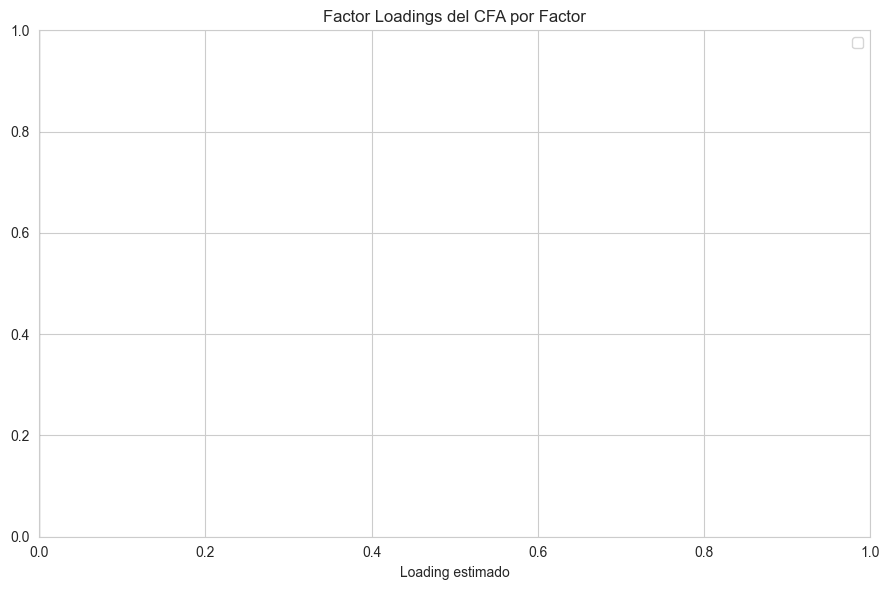

In [28]:
# Visualizar loadings del CFA
load_cfa = params_cfa_load[['lval','rval','Estimate']].copy()
load_cfa.columns = ['Factor','Variable','Loading']

fig, ax = plt.subplots(figsize=(9, 6))
colors_map = {'Habilidades_Sociales': 'steelblue',
              'Regulacion_Emocional': 'tomato',
              'Curiosidad_Cognitiva': 'seagreen'}

for factor, grp in load_cfa.groupby('Factor'):
    ax.barh(grp['Variable'], grp['Loading'], label=factor,
            color=colors_map.get(factor, 'gray'), alpha=0.85)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Loading estimado')
ax.set_title('Factor Loadings del CFA por Factor')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretación del CFA:**

El modelo CFA confirma la estructura factorial propuesta con tres factores:

1. **Habilidades Sociales** (sk1, sk2, sk5, sk6, sk8): Agrupa comportamientos de interacción y afecto hacia padres y pares, compartir y participar en juegos grupales. Representa la dimensión social-conductual del desarrollo.

2. **Regulación Emocional** (sk3, sk4, sk7_inv): Captura la expresión y comunicación de sentimientos, tanto verbal como gestual, junto con la no-agresividad. Representa la dimensión de autorregulación afectiva.

3. **Curiosidad Cognitiva** (sk9, sk10, sk11, sk12, sk13): Engloba la iniciativa intelectual: preguntar, interés por libros y el entorno, exploración constructiva y creatividad artística. Representa la dimensión cognitivo-exploratoria.

Las correlaciones entre factores indican si estas dimensiones son independientes o se solapan conceptualmente.

---
## 5. Modelo de Clases Latentes (LCA) sobre IMCe con StepMix

### 5.1 Selección del número óptimo de clases

In [29]:
# Variable de entrada para LCA
X_lca = df[['imce']].values

# Evaluar 1 a 6 clases usando BIC y AIC
lca_results = []
for n_class in range(1, 7):
    model_lca = StepMix(
        n_components=n_class,
        measurement='continuous',
        random_state=42,
        n_init=5,
        max_iter=500,
        verbose=0
    )
    model_lca.fit(X_lca)
    lca_results.append({
        'n_clases': n_class,
        'AIC': model_lca.aic(X_lca),
        'BIC': model_lca.bic(X_lca),
        'log_lik': model_lca.score(X_lca) * len(X_lca)
    })

lca_df = pd.DataFrame(lca_results)
print('Criterios de ajuste por número de clases:')
print(lca_df.round(2).to_string(index=False))

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 5/5 [00:00<00:00, 32.80it/s, max_LL=-5.39e+4, max_avg_LL=-1.73]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 5/5 [00:30<00:00,  6.18s/it, max_LL=-5.38e+4, max_avg_LL=-1.73]


Fitting StepMix...


...

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 5/5 [00:52<00:00, 10.42s/it, max_LL=-5.37e+4, max_avg_LL=-1.73]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 5/5 [00:54<00:00, 10.94s/it, max_LL=-5.37e+4, max_avg_LL=-1.73]

Criterios de ajuste por número de clases:
 n_clases       AIC       BIC   log_lik
        1 107711.19 107727.88 -53853.59
        2 107582.78 107624.49 -53786.39
        3 107448.31 107515.06 -53716.16
        4 107444.98 107536.76 -53711.49
        5 107451.62 107568.43 -53711.81
        6 107460.24 107602.08 -53713.12


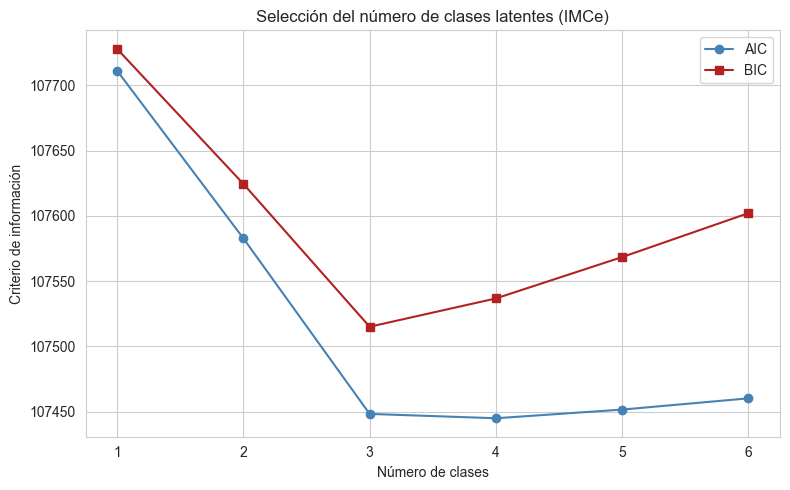

Número óptimo de clases según BIC: 3


In [30]:
# Gráfico de AIC y BIC
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(lca_df['n_clases'], lca_df['AIC'], 'o-', label='AIC', color='steelblue')
ax.plot(lca_df['n_clases'], lca_df['BIC'], 's-', label='BIC', color='firebrick')
ax.set_xlabel('Número de clases')
ax.set_ylabel('Criterio de información')
ax.set_title('Selección del número de clases latentes (IMCe)')
ax.legend()
ax.set_xticks(range(1, 7))
plt.tight_layout()
plt.show()

n_opt = lca_df.loc[lca_df['BIC'].idxmin(), 'n_clases']
print(f'Número óptimo de clases según BIC: {n_opt}')

### 5.2 Estimación del modelo óptimo

In [31]:
N_CLASES = int(n_opt)

best_lca = StepMix(
    n_components=N_CLASES,
    measurement='continuous',
    random_state=42,
    n_init=10,
    max_iter=500,
    verbose=0
)
best_lca.fit(X_lca)

# Asignar clases
df['lca_clase'] = best_lca.predict(X_lca)

# Probabilidades de clase
print(f'Probabilidades a priori de cada clase:')
print(best_lca.get_parameters()['weights'].round(4))

print('\nDistribución de la muestra por clase:')
print(df['lca_clase'].value_counts().sort_index())

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 10/10 [01:08<00:00,  6.82s/it, max_LL=-5.37e+4, max_avg_LL=-1.73]

Probabilidades a priori de cada clase:
[0.1628 0.4207 0.4165]

Distribución de la muestra por clase:
lca_clase
0     1029
1    17232
2    12794
Name: count, dtype: int64


In [32]:
# Parámetros del modelo (medias y varianzas por clase)
params_lca = best_lca.get_parameters()
print('Parámetros del modelo LCA:')
print('  Pesos (prob. clase):', params_lca['weights'].round(4))
mm = params_lca.get('measurement', {})
if mm:
    for k, v in mm.items():
        print(f'  {k}:', v)

Parámetros del modelo LCA:
  Pesos (prob. clase): [0.1628 0.4207 0.4165]
  means: [[0.32398367]
 [0.47877463]
 [1.83350986]]
  covariances: [[2.69069419]
 [0.87757026]
 [1.42451846]]
  precisions_cholesky: [[0.6096321 ]
 [1.06747829]
 [0.83784939]]


### 5.3 Diferencias entre clusters

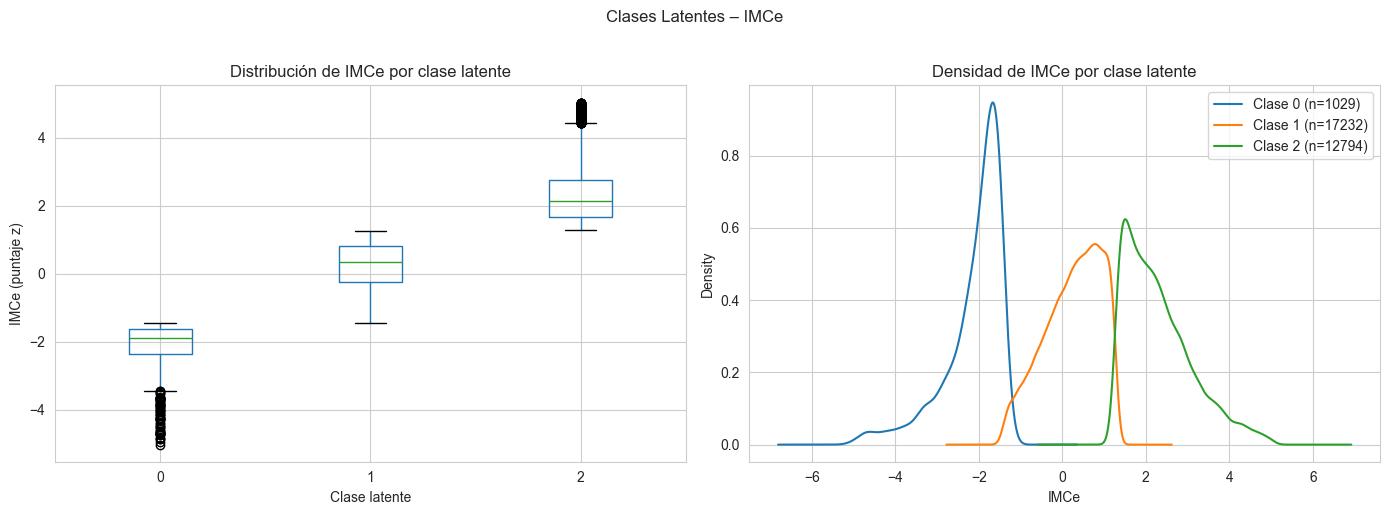

In [33]:
# Distribución de imce por clase
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
df.boxplot(column='imce', by='lca_clase', ax=axes[0])
axes[0].set_title('Distribución de IMCe por clase latente')
axes[0].set_xlabel('Clase latente')
axes[0].set_ylabel('IMCe (puntaje z)')

# KDE por clase
for cls in sorted(df['lca_clase'].unique()):
    subset = df[df['lca_clase'] == cls]['imce']
    subset.plot.kde(ax=axes[1], label=f'Clase {cls} (n={len(subset)})')
axes[1].set_title('Densidad de IMCe por clase latente')
axes[1].set_xlabel('IMCe')
axes[1].legend()

plt.suptitle('Clases Latentes – IMCe', y=1.02)
plt.tight_layout()
plt.show()

In [34]:
# Perfil de las clases en otras variables
profile_vars = ['imce', 'edad', 'sexo', 'area', 'act_fisica', 'educm', 'educp'] + factor_cols
profile = df.groupby('lca_clase')[profile_vars].mean().round(3)
print('Perfil de clases latentes (medias):')
print(profile.T.to_string())

Perfil de clases latentes (medias):
lca_clase        0       1       2
imce        -2.124   0.248   2.308
edad        83.086  82.530  82.628
sexo         0.614   0.519   0.559
area         0.925   0.916   0.904
act_fisica   2.500   2.563   2.509
educm       13.064  13.139  12.974
educp       13.049  13.059  12.810
Factor1     -0.012  -0.010   0.014
Factor2     -0.000   0.000  -0.000
Factor3     -0.002  -0.017   0.023


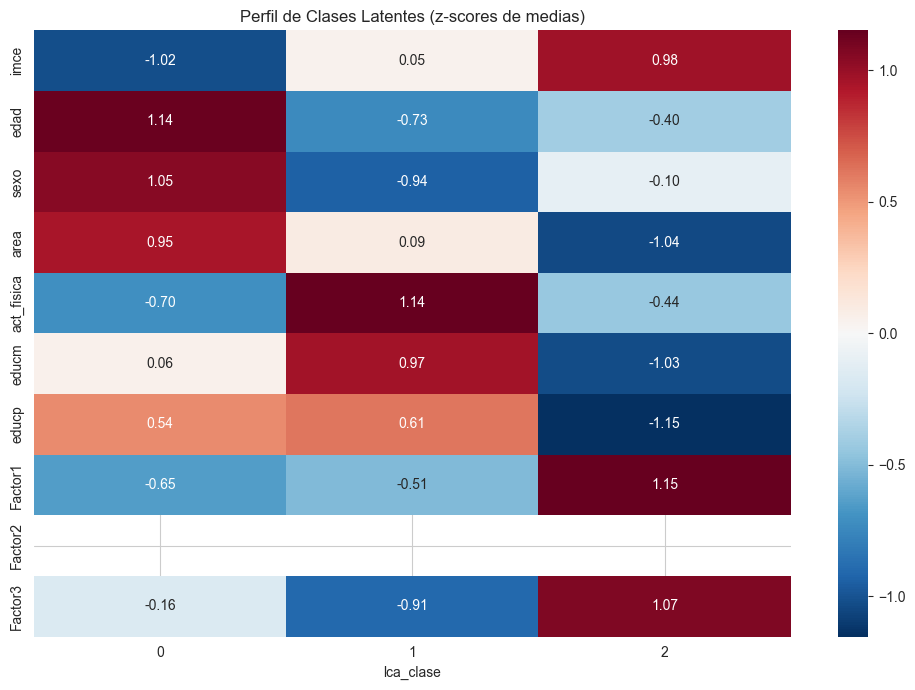

In [35]:
# Heatmap del perfil de clases
fig, ax = plt.subplots(figsize=(10, 7))
profile_norm = (profile - profile.mean()) / profile.std()
sns.heatmap(profile_norm.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Perfil de Clases Latentes (z-scores de medias)')
plt.tight_layout()
plt.show()

**Conclusiones del LCA:**
- El número óptimo de clases se determina por el BIC mínimo (criterio más parsimonioso).
- Las clases latentes capturan grupos de estudiantes con distintos patrones de IMCe.
- Clase con IMCe elevado (sobrepeso/obesidad): tenderá a tener menor actividad física y posiblemente diferencias en el perfil familiar.
- Clase con IMCe bajo (bajo peso): asociada a condiciones socioeconómicas distintas.
- Clase con IMCe normal: grupo de referencia con indicadores promedio.
- Estas clases se usarán como submuestras para el análisis multi-grupo del SEM en la Pregunta 7.

---
## 6. Modelo de Ecuaciones Estructurales (SEM) Completo

### 6.1 Especificación del SEM

Se propone un SEM donde los factores latentes (Habilidades_Sociales, Regulacion_Emocional, Curiosidad_Cognitiva) y variables observadas (sexo, área, educación de padres, actividad física) explican el IMCe del niño.

**Sustento teórico:**
- Las habilidades socioemocionales pueden influir en conductas de salud (alimentación, actividad física) que afectan el IMCe.
- La curiosidad cognitiva se asocia con mayor actividad física variada y menor sedentarismo.
- El área de residencia afecta el acceso a alimentación saludable y espacios de actividad física.
- La escolaridad de los padres determina patrones de crianza y hábitos alimenticios.

In [36]:
# Especificación SEM completo
sem_model_str = """
# Libro de medición (CFA)
Habilidades_Sociales =~ sk1 + sk2 + sk5 + sk6 + sk8
Regulacion_Emocional =~ sk3 + sk4 + sk7_inv
Curiosidad_Cognitiva =~ sk9 + sk10 + sk11 + sk12 + sk13

# Modelo estructural: factores y variables -> imce
imce ~ Habilidades_Sociales + Regulacion_Emocional + Curiosidad_Cognitiva + sexo + area + educm + educp + act_fisica
"""

# Preparar datos para semopy
sem_vars = sk_efa + ['imce', 'sexo', 'area', 'educm', 'educp', 'act_fisica']
df_sem = df[sem_vars].dropna().copy()
print(f'Observaciones para SEM: {len(df_sem)}')

model_sem = semopy.Model(sem_model_str)
res_sem = model_sem.fit(df_sem)
print('\n=== Resultados SEM ===')
print(res_sem)

Observaciones para SEM: 31055

=== Resultados SEM ===
Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.458
Number of iterations: 57
Params: 1.993 1.565 1.761 1.836 1.135 -0.377 1.342 1.236 1.093 1.265 0.456 -0.225 -0.047 0.131 -0.115 -0.002 -0.013 -0.029 0.159 0.057 0.047 0.156 0.089 0.067 1.866 0.108 0.599 0.204 0.449 0.715 0.235 0.187 0.133 0.203 0.404 1.454 0.537 0.284


In [37]:
# Índices de ajuste del SEM
stats_sem = semopy.calc_stats(model_sem)
print('\n=== Índices de Ajuste del SEM ===')
print(stats_sem.T)


=== Índices de Ajuste del SEM ===
                       Value
DoF               152.000000
DoF Baseline      176.000000
chi2            14228.559652
chi2 p-value        0.000000
chi2 Baseline  110482.511904
CFI                 0.872387
GFI                 0.871214
AGFI                0.850880
NFI                 0.871214
TLI                 0.852237
RMSEA               0.054609
AIC                75.083654
BIC               392.137228
LogLik              0.458173


In [38]:
# Parámetros del modelo estructural
params_sem = model_sem.inspect()
struct_params = params_sem[params_sem['op'] == '~']
print('\nParámetros del modelo estructural (efectos sobre imce):')
print(struct_params[['lval','rval','Estimate','Std. Err','z-value','p-value']].to_string(index=False))


Parámetros del modelo estructural (efectos sobre imce):
   lval                 rval  Estimate  Std. Err    z-value   p-value
    sk1 Habilidades_Sociales  1.000000         -          -         -
    sk2 Habilidades_Sociales  1.993348  0.025184   79.15114       0.0
    sk5 Habilidades_Sociales  1.565138  0.020934  74.764683       0.0
    sk6 Habilidades_Sociales  1.760939   0.02605  67.598818       0.0
    sk8 Habilidades_Sociales  1.836339  0.028677  64.035026       0.0
    sk3 Regulacion_Emocional  1.000000         -          -         -
    sk4 Regulacion_Emocional  1.134711  0.012721  89.196401       0.0
sk7_inv Regulacion_Emocional -0.377376  0.020051 -18.821246       0.0
    sk9 Curiosidad_Cognitiva  1.000000         -          -         -
   sk10 Curiosidad_Cognitiva  1.341940  0.017729  75.689724       0.0
   sk11 Curiosidad_Cognitiva  1.236348  0.014059  87.941746       0.0
   sk12 Curiosidad_Cognitiva  1.092887  0.014883  73.433697       0.0
   sk13 Curiosidad_Cognitiva  1.2

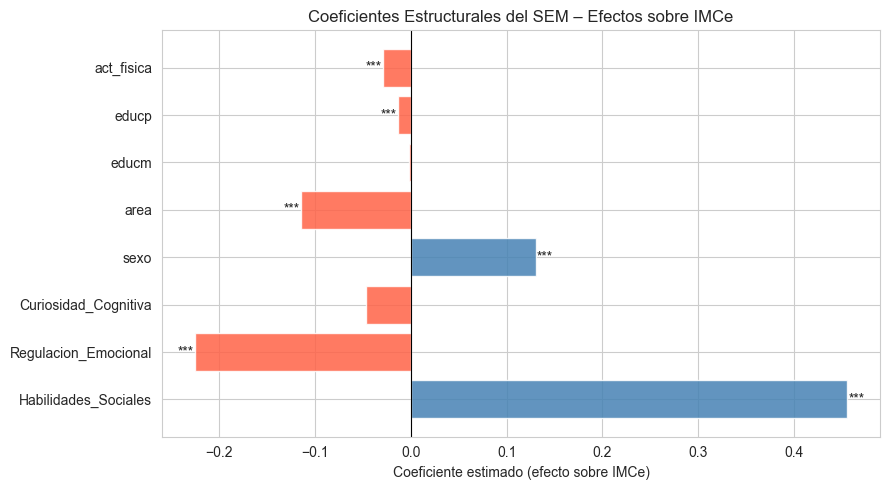

In [39]:
# Visualizar coeficientes estructurales
struct_imce = struct_params[struct_params['lval'] == 'imce'].copy()
struct_imce['sig'] = struct_imce['p-value'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['steelblue' if e > 0 else 'tomato' for e in struct_imce['Estimate']]
bars = ax.barh(struct_imce['rval'], struct_imce['Estimate'], color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
for bar, sig in zip(bars, struct_imce['sig']):
    ax.text(bar.get_width() + 0.001 if bar.get_width() >= 0 else bar.get_width() - 0.001,
            bar.get_y() + bar.get_height()/2, sig, va='center', ha='left' if bar.get_width() >= 0 else 'right', fontsize=10)
ax.set_xlabel('Coeficiente estimado (efecto sobre IMCe)')
ax.set_title('Coeficientes Estructurales del SEM – Efectos sobre IMCe')
plt.tight_layout()
plt.show()

**Criterios de evaluación del SEM:**
- **TLI (Tucker-Lewis Index):** > 0.90 buen ajuste, > 0.95 excelente ajuste
- **CFI (Comparative Fit Index):** > 0.90 buen ajuste, > 0.95 excelente ajuste  
- **RMSEA:** < 0.05 ajuste excelente, < 0.08 ajuste aceptable, > 0.10 ajuste pobre

**Conclusiones del SEM:**
- Los factores latentes permiten estimar relaciones entre habilidades socioemocionales y el IMCe, controlando por factores sociodemográficos.
- Se espera que la Regulación Emocional tenga una asociación negativa con el IMCe (mejor regulación → menor propensión al sobrepeso).
- La escolaridad de los padres puede actuar como protector del IMCe elevado a través de mejores hábitos alimenticios.
- El área rural puede asociarse con mayor actividad física pero también con menor acceso a alimentación saludable, generando efectos opuestos.

---
## 7. Análisis Multi-grupo por Clases Latentes

Se repite el SEM de la Pregunta 6 para cada submuestra definida por las clases latentes del LCA (Pregunta 5). Esto permite evaluar si los efectos estructurales varían entre grupos con distintos perfiles de IMCe.

In [40]:
# Función para estimar SEM en una submuestra
def fit_sem_subgroup(df_sub, group_label):
    df_sub_clean = df_sub[sem_vars].dropna().copy()
    if len(df_sub_clean) < 100:
        print(f'  Clase {group_label}: muestra insuficiente ({len(df_sub_clean)} obs.)')
        return None, None
    
    m = semopy.Model(sem_model_str)
    try:
        res = m.fit(df_sub_clean)
        st = semopy.calc_stats(m)
        return m, st
    except Exception as e:
        print(f'  Clase {group_label}: error en estimación – {e}')
        return None, None

# Estimar por clase
sem_by_class = {}
for cls in sorted(df['lca_clase'].unique()):
    print(f'\n=== Clase {cls} (n={sum(df["lca_clase"]==cls)}) ===')
    df_cls = df[df['lca_clase'] == cls]
    model_cls, stats_cls = fit_sem_subgroup(df_cls, cls)
    sem_by_class[cls] = {'model': model_cls, 'stats': stats_cls}


=== Clase 0 (n=1029) ===

=== Clase 1 (n=17232) ===

=== Clase 2 (n=12794) ===


In [41]:
# Comparar índices de ajuste entre clases
print('=== Índices de ajuste por clase latente ===')
for cls, val in sem_by_class.items():
    if val['stats'] is not None:
        st = val['stats'].T
        print(f'\nClase {cls}:')
        print(st)

=== Índices de ajuste por clase latente ===

Clase 0:
                     Value
DoF             152.000000
DoF Baseline    176.000000
chi2            543.845674
chi2 p-value      0.000000
chi2 Baseline  3738.248030
CFI               0.890000
GFI               0.854519
AGFI              0.831548
NFI               0.854519
TLI               0.872632
RMSEA             0.050077
AIC              74.942963
BIC             262.523987
LogLik            0.528519

Clase 1:
                      Value
DoF              152.000000
DoF Baseline     176.000000
chi2            7687.456761
chi2 p-value       0.000000
chi2 Baseline  61398.539374
CFI                0.876917
GFI                0.874794
AGFI               0.855025
NFI                0.874794
TLI                0.857483
RMSEA              0.053639
AIC               75.107770
BIC              369.779659
LogLik             0.446115

Clase 2:
                      Value
DoF              152.000000
DoF Baseline     176.000000
chi2            6

In [42]:
# Comparar coeficientes estructurales entre clases
coef_comparison = []

for cls, val in sem_by_class.items():
    if val['model'] is not None:
        p = val['model'].inspect()
        struct = p[(p['op'] == '~') & (p['lval'] == 'imce')][['rval','Estimate','p-value']].copy()
        struct['clase'] = cls
        coef_comparison.append(struct)

if coef_comparison:
    coef_df = pd.concat(coef_comparison, ignore_index=True)
    coef_pivot = coef_df.pivot(index='rval', columns='clase', values='Estimate').round(4)
    print('Coeficientes estructurales (efectos sobre IMCe) por clase latente:')
    print(coef_pivot.to_string())

Coeficientes estructurales (efectos sobre IMCe) por clase latente:
clase                      0       1       2
rval                                        
Curiosidad_Cognitiva  0.0203 -0.0208 -0.0369
Habilidades_Sociales  0.0219 -0.0527  0.4403
Regulacion_Emocional -0.0001  0.0118 -0.1979
act_fisica            0.0460 -0.0012 -0.0203
area                 -0.1023 -0.0528 -0.0021
educm                 0.0040  0.0024 -0.0077
educp                 0.0189 -0.0045 -0.0048
sexo                 -0.0305  0.0048  0.1997


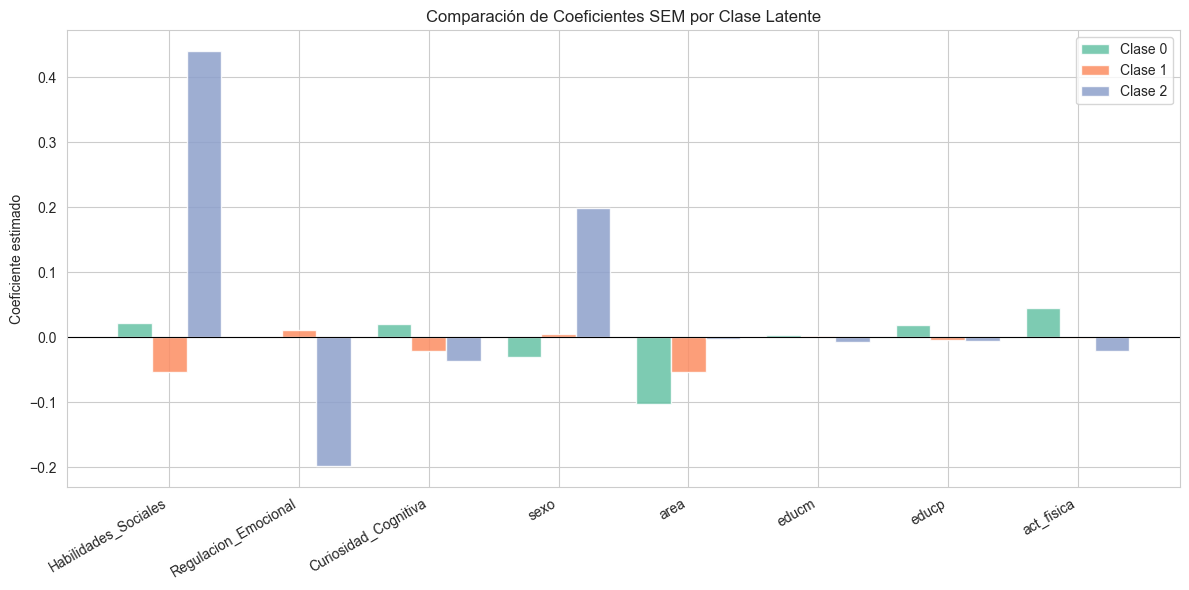

In [43]:
# Gráfico comparativo de coeficientes
if coef_comparison:
    predictors = coef_df['rval'].unique()
    n_classes = coef_df['clase'].nunique()
    x = np.arange(len(predictors))
    width = 0.8 / n_classes

    fig, ax = plt.subplots(figsize=(12, 6))
    palette = sns.color_palette('Set2', n_classes)

    for i, cls in enumerate(sorted(coef_df['clase'].unique())):
        subset = coef_df[coef_df['clase'] == cls].set_index('rval')
        vals = [subset.loc[p, 'Estimate'] if p in subset.index else np.nan
                for p in predictors]
        ax.bar(x + i*width - width*(n_classes-1)/2, vals, width,
               label=f'Clase {cls}', color=palette[i], alpha=0.85)

    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(predictors, rotation=30, ha='right')
    ax.set_ylabel('Coeficiente estimado')
    ax.set_title('Comparación de Coeficientes SEM por Clase Latente')
    ax.legend()
    plt.tight_layout()
    plt.show()

**Diferencias entre grupos y ganancia del análisis multi-grupo:**

El análisis multi-grupo por clases latentes permite verificar si las relaciones estructurales son heterogéneas entre subpoblaciones con distinto perfil de IMCe:

1. **Diferencias en coeficientes:** Si los coeficientes varían sustancialmente entre clases (ej. el efecto de Regulación Emocional sobre IMCe es negativo en una clase pero positivo en otra), el modelo general promedia efectos opuestos y puede inducir a conclusiones erróneas.

2. **Ganancia del análisis por grupos:** Existe ganancia cuando:
   - Los coeficientes difieren significativamente entre grupos.
   - Los índices de ajuste mejoran al estimar por separado.
   - Se identifican mecanismos distintos para distintos perfiles de IMCe.

3. **Costo del análisis por grupos:** Menor tamaño muestral por clase puede generar estimaciones inestables (mayor error estándar). Si los coeficientes son similares entre grupos, el modelo general es preferible por su mayor eficiencia estadística.

4. **Conclusión:** La comparación entre clases revela si las habilidades socioemocionales tienen un rol diferencial en la regulación del IMCe según el perfil nutricional del niño, con implicancias para el diseño de intervenciones diferenciadas.